## LoS vs NLoS Path Loss Characterization
### ASU Campus 3.5 GHz Ray-Tracing Scenario (DeepMIMO)

This notebook analyzes ray-traced path loss from the DeepMIMO ASU Campus
3.5 GHz scenario and compares it with the theoretical Friis free-space
path loss model, separating receiver locations into Line-of-Sight (LoS)
and Non-Line-of-Sight (NLoS) conditions.

**Goal:** Compare empirical and theoretical path loss to examine how
obstructions influence signal attenuation and how path-loss variability
differs between LoS and NLoS propagation.

See `../src/path_loss_analysis.py` for all analysis logic

In [ ]:
%pip install deepmimo -q


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sys
import importlib

sys.path.append('../src')

import path_loss_analysis as pla
importlib.reload(pla)

from path_loss_analysis import load_scenario, run_path_loss_analysis

### Load scenario

In [38]:
dataset = load_scenario('asu_campus_3p5')

Scenario "asu_campus_3p5" already exists in c:\Users\hp\Downloads\deepmimo-isac-analysis\notebooks\deepmimo_scenarios
Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 131931)


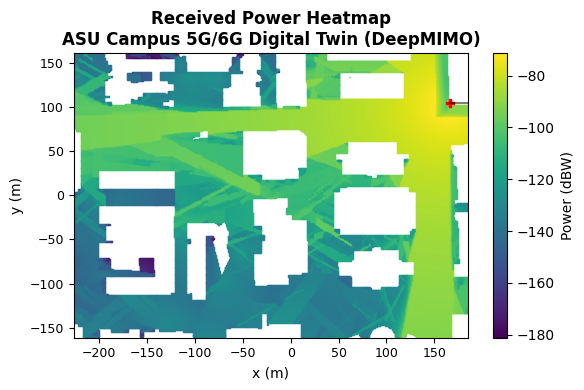

In [41]:
import matplotlib.pyplot as plt

dataset.power.plot()

ax = plt.gca()
fig = plt.gcf()

ax.set_title("Received Power Heatmap\nASU Campus 5G/6G Digital Twin (DeepMIMO)",
             fontsize=12, fontweight='bold', color='black')

ax.set_xlabel("x (m)", color='black', fontsize=10)
ax.set_ylabel("y (m)", color='black', fontsize=10)
ax.tick_params(colors='black', labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('black')

ax.grid(False)

cbar = ax.collections[0].colorbar
if cbar:
    cbar.ax.yaxis.set_tick_params(color='black')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')
    cbar.ax.set_ylabel("Power (dBW)", color='black')

fig.patch.set_facecolor('white')
ax.set_facecolor('white')

plt.tight_layout()
plt.show()


### Run the analysis


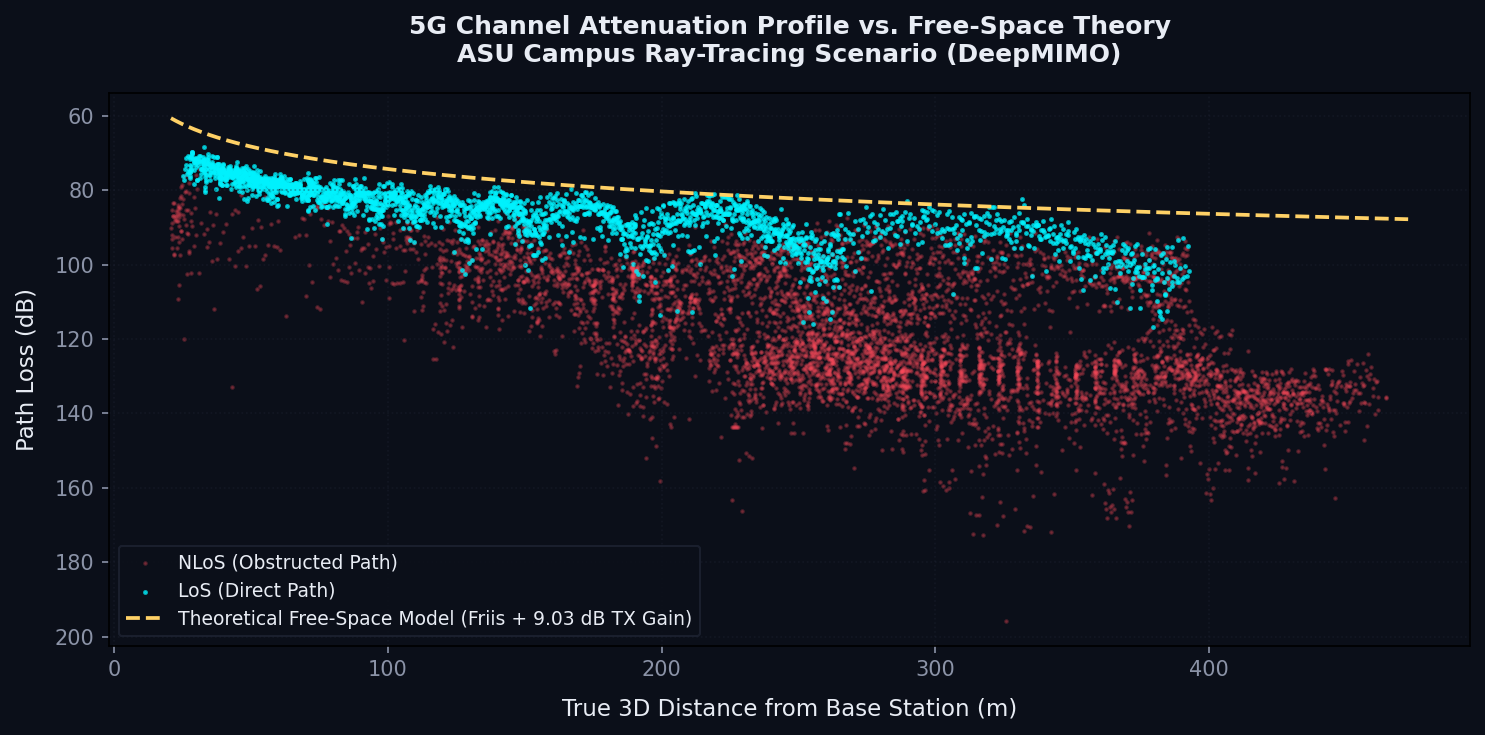

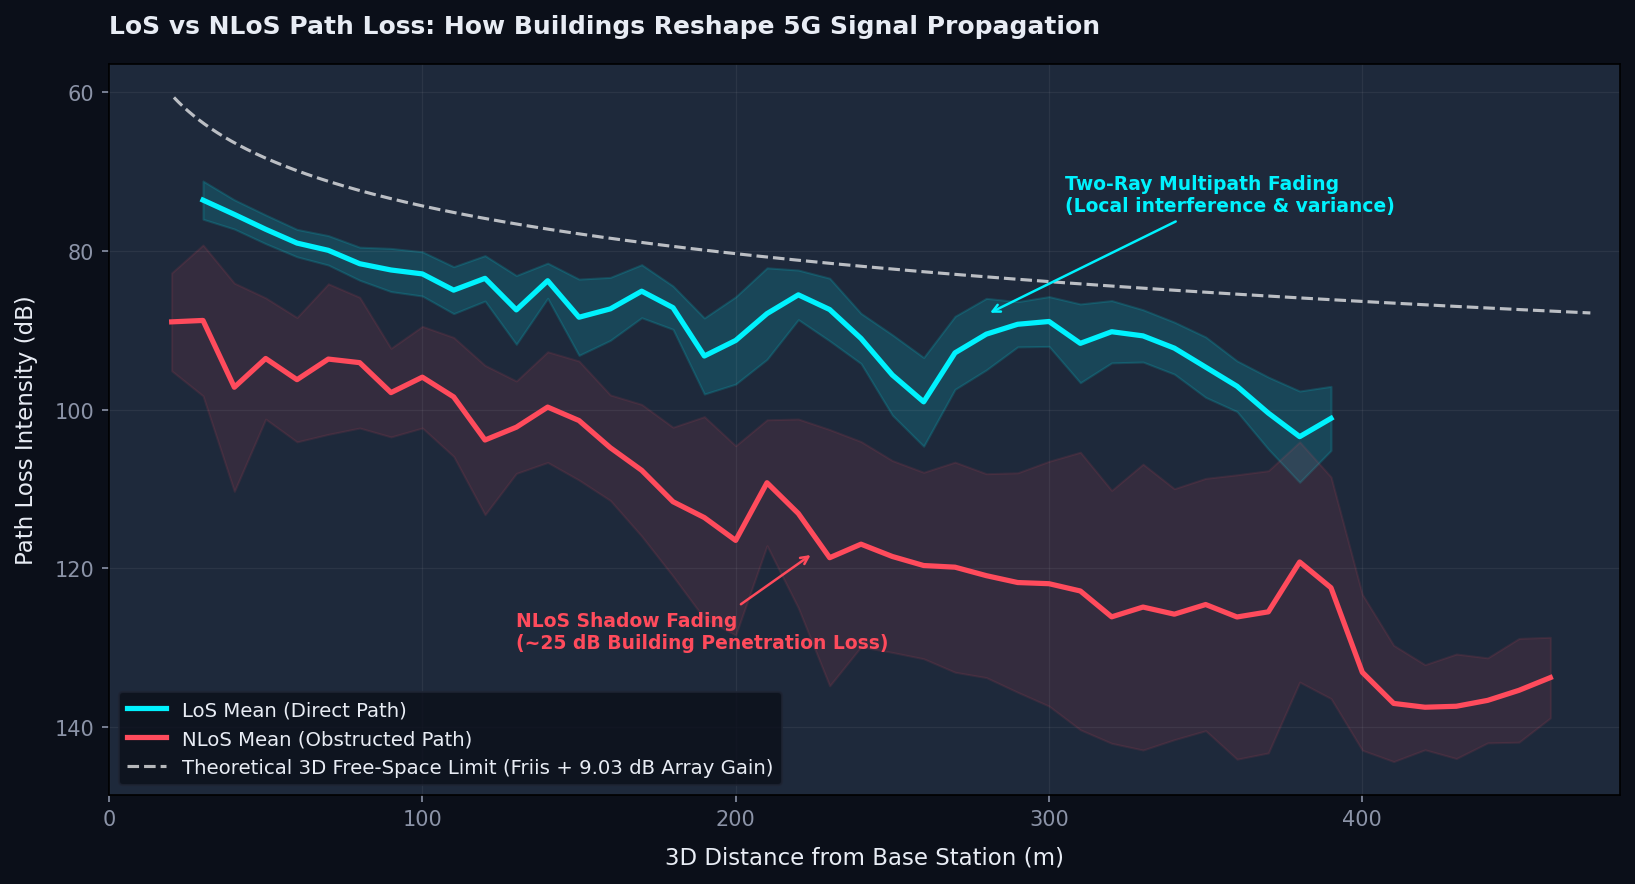

In [40]:
results = run_path_loss_analysis(dataset, save_dir='../plots')

### Interpretation

- **LoS points track close to the theoretical Friis curve**, with the gap
  widening slightly at longer range consistent with two-ray multipath
  fading rather than a modeling error.
- **NLoS points sit well below the LoS curve**, consistent with roughly
  25 dB of building penetration / shadow-fading loss on this campus layout.
- The spread (std band) is visibly wider for NLoS than LoS, which makes
  sense: obstructed paths depend heavily on *which* building/angle is in
  the way, while LoS paths are dominated by distance alone.

This is the kind of gap a link-budget designer needs to plan around
free-space math alone underestimates real attenuation once buildings are
in the picture.
